# Deconvolution with Ridge Regression

In [3]:
import mne
import pandas as pd
import numpy as np
import math
import re
from collections import namedtuple
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import seaborn as sns
from sklearn.model_selection import LeaveOneOut, KFold
from sklearn.linear_model import Ridge
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import fdrcorrection
from IPython.display import clear_output

In [4]:
DATA_DIR = "/Users/jowanglin/regression-based_ERP/data/eeg/crystal"
STIMULI_EXCEL = "/Users/jowanglin/regression-based_ERP/data/stimuli/CRYSTAL_master-sheet.xlsx"

SOA = 0.36     # in seconds
DOWNSAMPLE_SFREQ = 100.0  # downsample to 100.0 Hz
N_WORDS = 7

RIDGE_TOL = 1e-5
MAX_ITER = 20000
RANDOM_STATE = 42

#### Construct design matrix (intercept + log-transformed word position) with time lag
- Regress on Words 1-7 (many trials don't have 8, 9, 10; note that 4 trials don't have 7 either): Word 1 onset to 0.36 s post Word 8 onset (not touching Word 9)
    > By "don't have 7, I mean Word 7 is already the final word, which is the original experimental critical word, hence where the manipulations are and not ideal for deconvolution regression for plain word position effects."
    - Total number of samples = SOA * 7 * sfreq
- Dimension will depend on sampling rate
    - Better to downsample so the matrix rank is healthier
    - (Alternative is to average per time segment, e.g., average every 10 ms)
- Assuming the EEG response to each word lasts 1.0 s
- Check design matrix rank
- Check condition number
    - Full rank but high condition number $\rightarrow$ consider Ridge instead of vanilla OLS

In [ ]:
def build_design(*, soa: float, sfreq: float, n_words: int, response_lag: float, rank_tol: float=1e-3):
    DeconvDesignMatrix = namedtuple("DeconvDesignMatrix",
                                    ["n_lags", "X_intercept", "X_full", "rank", "singular_vals", "condition_num"])

    n_time_samples = int(round(soa * n_words * sfreq))
    n_lags = int(round(response_lag * sfreq))
    soa_samples = int(round(soa * sfreq))

    X_intercept = np.zeros((n_time_samples, n_lags), dtype=float)
    X_word_pos = np.zeros((n_time_samples, n_lags), dtype=float)

    positions = range(1, n_words + 1)
    for i, pos in enumerate(positions):
        valid_range = min(n_time_samples - i * soa_samples, n_lags)
        X_intercept[i * soa_samples : i * soa_samples + valid_range, : valid_range] += np.eye((valid_range))
        X_word_pos[i * soa_samples : i * soa_samples + valid_range, : valid_range] += math.log(pos) * np.eye(valid_range)

    X_full = np.hstack((X_intercept, X_word_pos))
    rank = np.linalg.matrix_rank(X_full, tol=rank_tol)
    singular_vals = np.linalg.svd(X_full, compute_uv=False)
    condition_num = np.linalg.cond(X_full)

    return DeconvDesignMatrix(n_lags, X_intercept, X_full, rank, singular_vals, condition_num)


In [722]:
deconv_design_matrix = build_design(soa=SOA,
                                    sfreq=DOWNSAMPLE_SFREQ,
                                    n_words=N_WORDS,
                                    response_lag=0.7,
                                    rank_tol=1e-2)
X_intercept, X_full = deconv_design_matrix.X_intercept, deconv_design_matrix.X_full

print(f"X_full.shape = {X_full.shape}")
print(f"rank = {deconv_design_matrix.rank}")
print(f"condition number = {deconv_design_matrix.condition_num}")
print(f"5 largest singular values: {deconv_design_matrix.singular_vals[:5]}")
print(f"5 smallest singular values: {deconv_design_matrix.singular_vals[-5:]}")

X_full.shape = (252, 140)
rank = 140
condition number = 100.93671892253454
5 largest singular values: [5.78157345 5.78157345 5.78157345 5.78157345 5.78157345]
5 smallest singular values: [0.05727919 0.05727919 0.05727919 0.05727919 0.05727919]


#### Get the dependent variable: sampled time points of EEG signals spanning Words 1-7
- Epoch each subject's continuous data: time-lock to Word 1 onset, epoch length is 0.36 s * 7 = 2.52 s
    - <strong>No baseline correction</strong>
- Since ISI is fixed throughout, there is essentially no change in temporal structure across different Word 1-7 segments (e.g., the design matrix is repeated vertically for `total_n_trials = 208` times), so fitting the regression is equivalent to fitting a single, non-repeated design matrix to the average Word 1-7 segment (the solutions, i.e., coefficients, are equal, <i>but the R^2's are not</i>).
    > However, if other experimental factors are added to the regression, this will not hold.
- Therefore, it's more straightforward to just create an Evoked object for each subject.

In [ ]:
def generate_time_lock_events(position_range: tuple,
                              remove: tuple | list | None=None):
    constraint = "high_constraint", "low_constraint"
    word_positions = [f"w{i}" for i in range(position_range[0], position_range[1]+1)]
    time_lock_events = [f"{w}/{c}" for w in word_positions for c in constraint]
    if remove is not None:
        for r in remove:
            time_lock_events.remove(r)
    return time_lock_events

def revise_annot(df_annot: pd.DataFrame, *,
                 fixation: str, non_final: str, item_codes: list|tuple,
                 high_constraint: tuple, low_constraint: tuple) -> mne.Annotations:   
    desc = list(df_annot["description"])
    desc_revised = desc.copy()
    for i, d in enumerate(desc):
        if d == fixation:
            step = 1
        elif d == non_final:
            desc_revised[i] = "w" + str(step) + "/high_constraint"
            step += 1
        elif d in item_codes:
            if desc[i-1] == fixation:
                desc_revised[i] = "w" + str(step) + "/high_constraint"
                step += 1
            elif desc[i-1] == non_final:
                desc_revised[i] = "w" + str(step) + "/high_constraint"
                #step = 0
        elif d in high_constraint:
            step = 0
        elif d in low_constraint:
            desc_revised[i-step: i] = [s.replace("/high_constraint", "/low_constraint")
                                            for s in desc_revised[i-step: i]]
            step = 0
    
    annot = mne.Annotations(onset=df_annot["onset"], duration=df_annot["duration"], description=desc_revised)
    return annot

def get_segments_of_consecutive_words(raw: mne.io.Raw, *,
                                      fixation: str, non_final: str, item_codes: str,
                                      high_frame_val: str, low_frame_val: str,
                                      soa: float, n_words: int,
                                      downsample_sfreq: float,
                                      compute_evoked: bool=True):
    
    df_annot = pd.DataFrame(raw.annotations)
    annot_revised = revise_annot(df_annot,
                                 fixation=fixation, non_final=non_final, item_codes=item_codes,
                                 high_frame_val=high_frame_val, low_frame_val=low_frame_val)
    raw.set_annotations(annot_revised)

    events, event_id = mne.events_from_annotations(raw)
    
    time_lock_events = generate_time_lock_events(position_range=(1, 1))  # only time lock to word 1
    print(time_lock_events)
    time_locks = {k: v for k, v in event_id.items() if k in time_lock_events}

    epochs = mne.Epochs(raw,
                        events=events, event_id=time_locks,
                        tmin=0.0, tmax=soa*n_words, baseline=None,  # no baseline correction
                        on_missing="raise",
                        preload=True,
                        verbose=True)
    epochs = epochs.resample(sfreq=downsample_sfreq)

    if compute_evoked:
        evoked = epochs.average(method="mean", by_event_type=False)  # one evoked per subject
        return epochs, evoked
    else:
        return epochs

In [ ]:
df_stimuli = pd.read_excel(STIMULI_EXCEL, sheet_name="Overall")
fixation = "210"
non_final = "220"
item_codes = tuple(str(i) for i in range(df_stimuli["W1_code"].min(), df_stimuli["W1_code"].max()+1))
high_frame_val = ("240", "241", "242", "243")
low_frame_val = ("244", "245", "246", "247")

list_of_epochs, list_of_evokeds = [], []
for num in range(1, 28):
    raw_file_name = f"subj{str(num).zfill(3)}_reref_filt.set"
    try:
        raw = mne.io.read_raw_eeglab(f"{DATA_DIR}/{raw_file_name}", preload=True, verbose=False)
    except FileNotFoundError:
        continue
    print(f"subj{str(num).zfill(3)}")
    epochs, evoked = get_segments_of_consecutive_words(raw,
                                                       fixation=fixation,
                                                       non_final=non_final, item_codes=item_codes,
                                                       high_frame_val=high_frame_val, low_frame_val=low_frame_val,
                                                       soa=SOA, n_words=N_WORDS,
                                                       downsample_sfreq=DOWNSAMPLE_SFREQ,
                                                       compute_evoked=True)
    list_of_epochs.append(epochs)
    list_of_evokeds.append(evoked)

clear_output()

In [ ]:
epochs_length_check = np.array([len(e) for e in list_of_epochs], dtype=int)
sfreq_check = np.array([e.info["sfreq"] for e in list_of_epochs], dtype=float)
sampled_times_check = np.array([len(e.times) for e in list_of_evokeds], dtype=int)
print(f"Number of epochs = 208 (all): {np.all(epochs_length_check == 208)}")
print(f"Downsampled to 100.0 Hz (all): {np.all(sfreq_check == 100.0)}")
print(f"""Number of time samples = SOA * N_WORDS * SFREQ = 252 (all):
                         {np.all(sampled_times_check == int(round(SOA * N_WORDS * DOWNSAMPLE_SFREQ)))}""")

Number of epochs = 208 (all): True
Downsampled to 100.0 Hz (all): True
Number of time samples = ISI * N_WORDS * SFREQ = 252 (all):
                         True


#### Nested CV (cross-validation) per-subject

In [ ]:
def refit(subj_data: np.ndarray, *, X: np.ndarray,
          ch_roi: list,
          alpha_range: np.ndarray,
          n_splits: int=5, ridge_tol: float=1e-4, solver: str="auto", max_iter: int|None=None,
          subj_data_mean: np.ndarray | None=None):
    RefitResults = namedtuple("RefitResults", ["coef", "pred", "r2", "solver", "n_iter"])
    
    if subj_data_mean is None:
        subj_data_mean = np.mean(subj_data, axis=0)

    cv_results = tune_alpha(subj_data, X=X,
                            alpha_range=alpha_range,
                            n_splits=n_splits,
                            ridge_tol=ridge_tol,
                            solver=solver,
                            max_iter=max_iter)
    ridge = Ridge(alpha=cv_results.best_alpha,
                  fit_intercept=False,         
                  tol=ridge_tol,
                  solver="auto",
                  positive=False,              
                  max_iter=max_iter,
                  random_state=RANDOM_STATE)
    
    n_roi_channels, n_time_samples = subj_data_mean.shape
    assert n_roi_channels == len(ch_roi)

    reconstruction = np.empty((n_roi_channels, n_time_samples))
    coefs = np.empty((n_roi_channels, X.shape[1]))
    scores, solvers, n_iters = {}, {}, {}

    for i, ch in enumerate(ch_roi):
        ridge.fit(X, subj_data_mean[i, :])
        reconstruction[i, :] = ridge.predict(X)
        coefs[i, :] = ridge.coef_
        scores[ch] = ridge.score(X, subj_data_mean[i, :])
        solvers[ch] = ridge.solver_
        n_iters[ch] = ridge.n_iter_

    refit_results = RefitResults(coefs, reconstruction, scores, solvers, n_iters)
    return cv_results, refit_results


def tune_alpha(ridge_data: np.ndarray, *, X: np.ndarray,
               alpha_range: np.ndarray,
               loo: bool=False, n_splits: int | None=None,
               ridge_tol: float=1e-4, solver: str="auto", max_iter: int|None=None,
               verbose: bool=False):
    """ridge_data.shape = (n_trials, n_roi_channels, n_time_samples)
                          if group-level (i.e., doing LOO), n_trials = n_subjects (but this does not work well)
       design matrix X.shape = (n_time_samples, n_predictors * n_lags)
       alpha_range in single-subject-level range (not divided by n_subj-1)"""
    ScoreResults = namedtuple("ScoreResults", ["train_scores", "train_mean", "train_std",
                                               "valid_scores", "valid_mean", "valid_std"])
    CVResults = namedtuple("CVResults", ["fold_scores", "best_mean_score", "best_alpha"])   
    
    n_trials, n_roi_channels, _ = ridge_data.shape
    if loo:
        splitter = LeaveOneOut()
        n_splits = n_trials
    else:
        if n_splits is None:
            n_splits = 5
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    
    fold_scores = {}
    for alpha in alpha_range:
        if verbose:
            print(f"ALPHA = {alpha}")
        train_scores = np.empty((n_splits, n_roi_channels))
        valid_scores = np.empty((n_splits, n_roi_channels))
        for i, (train_idx, valid_idx) in enumerate(splitter.split(ridge_data)):
            if verbose:
                print(f"  FOLD {i+1}")

            y_train, y_valid = ridge_data[train_idx], ridge_data[valid_idx]

            X_train = np.vstack([X for _ in train_idx])
                                                   
            ridge = Ridge(alpha=alpha,
                      fit_intercept=False,         # already constructed time-convolved intercept
                      tol=ridge_tol,
                      solver=solver,
                      positive=False,              # don't force coefficients to be positive (when solver is 'lbfgs')
                      max_iter=max_iter,
                      random_state=RANDOM_STATE)
    
            for j in range(n_roi_channels):
                if verbose:
                    print(f"    Channel Index {j}")
    
                y_train_per_ch = np.hstack([a for a in y_train[:, j, :]])
                y_train_per_ch_for_score = np.mean(y_train[:, j, :], axis=0)
                y_valid_per_ch_for_score = np.mean(y_valid[:, j, :], axis=0)
                ridge.fit(X_train, y_train_per_ch)
                train_scores[i, j] = ridge.score(X, y_train_per_ch_for_score)
                valid_scores[i, j] = ridge.score(X, y_valid_per_ch_for_score)
        
        train_mean, train_std = np.mean(train_scores, axis=None), np.std(train_scores, axis=None)
        valid_mean, valid_std = np.mean(valid_scores, axis=None), np.std(valid_scores, axis=None)
        fold_scores[alpha] = ScoreResults(train_scores, train_mean, train_std,
                                          valid_scores, valid_mean, valid_std)
    
    mean_scores = np.array([fold_scores[alpha].valid_mean for alpha in alpha_range])
    best_mean_score = np.max(mean_scores)
    best_alpha = alpha_range[np.argmax(mean_scores)]

    return CVResults(fold_scores, best_mean_score, best_alpha)


def nested_cv(subj_data: np.ndarray, *, X: np.ndarray,
              alpha_range: np.ndarray,
              n_splits_outer: int=5, n_splits_inner: int=5,
              ridge_tol: float=1e-4, solver: str="auto", max_iter: int|None=None,
              verbose: bool=False):
    _, n_roi_channels, n_time_samples = subj_data.shape
    assert X.shape[0] == n_time_samples

    kf = KFold(n_splits=n_splits_outer, shuffle=True, random_state=RANDOM_STATE)
    
    outer_scores = np.empty((n_splits_outer, n_roi_channels))
    best_alphas = np.empty((n_splits_outer, ))
    for i, (train_outer_idx, test_outer_idx) in enumerate(kf.split(subj_data)):
        if verbose:
            print(f"OUTER FOLD {i+1}")
        
        y_train_outer, y_test_outer = subj_data[train_outer_idx], subj_data[test_outer_idx]
        X_train_outer = np.vstack([X for _ in train_outer_idx])

        cv_results = tune_alpha(y_train_outer, X=X,
                                alpha_range=alpha_range,
                                loo=False,
                                n_splits=n_splits_inner,
                                ridge_tol=ridge_tol,
                                max_iter=max_iter,
                                solver=solver,
                                verbose=False)
        best_alphas[i] = cv_results.best_alpha

        ridge = Ridge(alpha=cv_results.best_alpha,
                      fit_intercept=False,         
                      tol=ridge_tol,
                      solver=solver,
                      positive=False,              
                      max_iter=max_iter,
                      random_state=RANDOM_STATE)
        for j in range(n_roi_channels):
            y_train_outer_per_ch = np.hstack([a for a in y_train_outer[:, j, :]])
            ridge.fit(X_train_outer, y_train_outer_per_ch)
            y_test_outer_per_ch = np.mean(y_test_outer[:, j, :], axis=0)
            outer_scores[i, j] = ridge.score(X, y_test_outer_per_ch)
    return outer_scores, best_alphas
        
            

> $\downarrow$ This takes about 15 mins...

In [ ]:
ch_roi = ["CZ", "C3", "C4", "CP3", "CP4", "CPZ"]
ch_roi_to_idx = {ch: idx for idx, ch in enumerate(list_of_epochs[0].ch_names)}
alpha_range = np.logspace(-3, 3, 25)  # 0.001 -> 1000

outer_scores_full_per_subj = np.empty((len(list_of_epochs), ), dtype=object)
outer_scores_intercept_per_subj = np.empty((len(list_of_epochs), ), dtype=object)
best_alphas_per_subj = []
for i, epochs in enumerate(list_of_epochs):
    print(f"subject index [{i}]...")
    subj_data = epochs.get_data(units="uV", picks=ch_roi)
    print(">> intercept-only")
    outer_scores_intercept, best_alphas_intercept = nested_cv(subj_data, X=X_intercept,
                                                             alpha_range=alpha_range,
                                                             n_splits_outer=5, n_splits_inner=5,
                                                             ridge_tol=1e-4, solver="auto", max_iter=MAX_ITER,
                                                             verbose=True)
    outer_scores_intercept_per_subj[i] = outer_scores_intercept
    print(">> full model")
    outer_scores_full, best_alphas_full = nested_cv(subj_data, X=X_full,
                                                    alpha_range=alpha_range,
                                                    n_splits_outer=5, n_splits_inner=5,
                                                    ridge_tol=1e-4, solver="auto", max_iter=MAX_ITER,
                                                    verbose=True)
    outer_scores_full_per_subj[i] = outer_scores_full

    best_alphas_per_subj.append((best_alphas_intercept, best_alphas_full))
    clear_output()

In [634]:
# np.save("outer_scores_full_per_subj_roi.npy", outer_scores_full_per_subj)
# np.save("outer_scores_intercept_per_subj_roi.npy", outer_scores_intercept_per_subj)

delta_r2_per_subj = outer_scores_full_per_subj - outer_scores_intercept_per_subj   
delta_r2_per_subj = np.array([d for d in delta_r2_per_subj])                       # shape (n_subj, n_splits_outer, n_ch_roi)
delta_r2_per_subj_fold_mean = np.mean(delta_r2_per_subj, axis=1)                   # shape (n_subj, n_ch_roi)

outer_scores_full_per_subj = np.array([s for s in outer_scores_full_per_subj])
outer_scores_intercept_per_subj = np.array([s for s in outer_scores_intercept_per_subj])
outer_scores_full_per_subj_mean = np.mean(np.mean(outer_scores_full_per_subj, axis=1), axis=0)
outer_scores_intercept_per_subj_mean = np.mean(np.mean(outer_scores_intercept_per_subj, axis=1), axis=0)

improve = [ttest_1samp(delta_r2_per_subj_fold_mean[:, i], 0.0, alternative="greater")
                                           for i in range(delta_r2_per_subj.shape[-1])]
ts = [im.statistic for im in improve]
ps = [im.pvalue for im in improve]
_, qs = fdrcorrection(ps, alpha=0.01, method="indep", is_sorted=False)
improve_df = pd.DataFrame({"R^2 (full)": outer_scores_full_per_subj_mean,
                           "R^2 (intercept)": outer_scores_intercept_per_subj_mean,
                           "delta R^2": np.mean(delta_r2_per_subj_fold_mean, axis=0),
                           "t-statistic": ts, "p-val": ps, "q-val (fdr)": qs})
improve_df = improve_df.rename(index={ch_roi.index(ch): ch for ch in ch_roi})
display(improve_df)


,R^2 (full),R^2 (intercept),delta R^2,t-statistic,p-val,q-val (fdr)
CZ,0.364408,0.229441,0.134967,4.476265,0.000129,0.000227
C3,0.278347,0.128272,0.150075,4.541861,0.000111,0.000227
C4,0.081082,-0.056251,0.137333,3.988082,0.000394,0.000472
CP3,-0.207568,-0.310834,0.103266,3.479978,0.001253,0.001253
CP4,0.118019,-0.027147,0.145166,4.821655,0.000059,0.000227
CPZ,0.233407,0.116184,0.117223,4.407678,0.000151,0.000227


#### Nested CV Results
Model comparison:
- <strong>Adding log-transformed word position into the time-lagged deconvolution model as a predictor in Ridge regression adds predictive / explanatory power compared to the intercept-only model</strong>
- This does not yet show that the word-position coefficients are in the expected direction (should be positive) in the N400 time window.
   - $\rightarrow$ Re-tune model on each subject separately to find each subject's best alpha and refit on full data, then asses the coefficients.

amplitude = beta_0 * 1 + beta_1 * word_pos + beta_2 * val

In [649]:
subj_alpha_tuned, subj_refit = [], []
for epochs, evoked in zip(list_of_epochs, list_of_evokeds):
    subj_epochs_data = epochs.get_data(units="uV", picks=ch_roi)
    subj_evoked_data = evoked.get_data(units="uV", picks=ch_roi)

    cv_results, refit_results = refit(subj_epochs_data,
                                      X=X_full,
                                      ch_roi=ch_roi,
                                      alpha_range=alpha_range,
                                      n_splits=5,
                                      ridge_tol=RIDGE_TOL,
                                      solver="auto",
                                      max_iter=MAX_ITER,
                                      subj_data_mean=subj_evoked_data)
    subj_alpha_tuned.append(cv_results)
    subj_refit.append(refit_results)

In [715]:
subj_refit_r2s = [s.r2 for s in subj_refit]
subj_alphas = [float(s.best_alpha) for s in subj_alpha_tuned]
print(subj_alphas)

[0.05623413251903491, 17.78279410038923, 0.31622776601683794, 0.05623413251903491, 0.1778279410038923, 0.1, 17.78279410038923, 17.78279410038923, 10.0, 0.05623413251903491, 0.5623413251903491, 5.623413251903491, 31.622776601683793, 0.05623413251903491, 0.1778279410038923, 10.0, 0.1778279410038923, 0.05623413251903491, 0.03162277660168379, 0.5623413251903491]


In [678]:
coefs = np.array([subj_refit[i].coef for i in range(len(subj_refit))])
intercept, beta = np.split(coefs, 2, axis=-1)
reconstruct = np.array([subj_refit[i].pred for i in range(len(subj_refit))])

n400_window = int(round(0.25 * DOWNSAMPLE_SFREQ)), int(round(0.5 * DOWNSAMPLE_SFREQ))
beta_n400 = beta[:, :, n400_window[0]: n400_window[1]+1]
print(beta_n400.shape)

beta_ts, beta_ps = ttest_1samp(beta_n400, popmean=0, axis=0)  # shape (6, 26)
reject, beta_qs = fdrcorrection(beta_ps.ravel(), alpha=0.05)
reject = reject.reshape(beta_ps.shape)
beta_qs = beta_qs.reshape(beta_ps.shape)


(20, 6, 26)


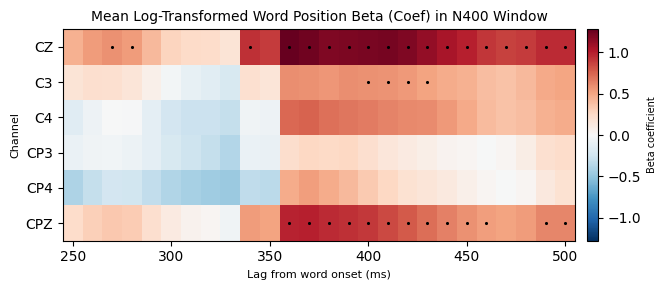

Black dots are p < 0.05 (t-test, uncorrected).


In [717]:
times_ms = np.arange(250, 501, 10) # 250, 260, ..., 500
assert beta_n400.shape[2] == len(times_ms)

heat_data = beta_n400.mean(axis=0) # shape: (6, 26) subject-mean beta heatmap: channels × time
sig_mask = beta_ps < 0.05
#sig_mask = reject

fig, axes = plt.subplots(figsize=(7, 3))

# pcolormesh wants bin edges, not centers
dt = 10 # ms
time_edges = np.r_[times_ms - dt / 2, times_ms[-1] + dt / 2]
channel_edges = np.arange(len(ch_roi) + 1)

vmax = np.nanmax(np.abs(heat_data))
mesh = axes.pcolormesh(time_edges,
                     channel_edges,
                     heat_data,
                     shading="auto",
                     cmap="RdBu_r",
                     vmin=-vmax,
                     vmax=vmax)

yy, xx = np.where(sig_mask)
axes.scatter(times_ms[xx], yy+0.5, marker=".", s=20, color="black", linewidth=0)

axes.set_yticks(np.arange(len(ch_roi)) + 0.5)
axes.set_yticklabels(ch_roi)
axes.invert_yaxis()

axes.set_xticks(np.arange(250, 501, 50))
axes.set_xlabel("Lag from word onset (ms)", fontsize=8)
axes.set_ylabel("Channel", fontsize=8)
axes.set_title("Mean Log-Transformed Word Position Beta (Coef) in N400 Window", fontsize=10)

axes.set_xticks(times_ms, minor=True)
axes.set_yticks(np.arange(len(ch_roi)) + 1, minor=True)
# axes.grid(which="minor", color="white", linewidth=0.45)
axes.tick_params(axis="both", which="minor", bottom=False, left=False, labelsize=7.5)

cbar = fig.colorbar(mesh, ax=axes, pad=0.02)
cbar.set_label("Beta coefficient", fontsize=7)

fig.tight_layout()
plt.show()

print("Black dots are p < 0.05 (t-test, uncorrected).")

In [693]:
beta_n400_mean = np.mean(beta_n400, axis=-1)  # average over time window (last axis)
rows, p_vals = [], []
for j, ch in enumerate(ch_roi):
    vals = beta_n400_mean[:, j]
    res = ttest_1samp(vals, 0.0, alternative="greater")
    rows.append({"channel": ch,
                 "mean_beta": vals.mean(),
                 "median_beta": np.median(vals),
                 "t-statistc": res.statistic,
                 "p-val": res.pvalue,
                 "# coef > 0": np.sum(vals > 0),
                 "# coef <= 0": np.sum(vals <= 0),})
    p_vals.append(res.pvalue)
reject, q_vals = fdrcorrection(p_vals, alpha=0.05)
beta_summary = pd.DataFrame(rows)
beta_summary["q-val (fdr)"] = q_vals
beta_summary["H0 rejected (fdr)"] = reject
display(beta_summary)

,channel,mean_beta,median_beta,t-statistc,p-val,# coef > 0,# coef <= 0,q-val (fdr),H0 rejected (fdr)
0,CZ,0.832867,0.519482,3.154338,0.002611,15,5,0.015665,True
1,C3,0.323068,0.127321,1.318236,0.101548,11,9,0.203097,False
2,C4,0.267935,-0.061123,0.857940,0.200809,9,11,0.301214,False
3,CP3,0.019163,-0.083859,0.105463,0.458557,7,13,0.526281,False
4,CP4,-0.017509,-0.218622,-0.066800,0.526281,7,13,0.526281,False
5,CPZ,0.531684,-0.020962,2.104615,0.024433,10,10,0.073298,False


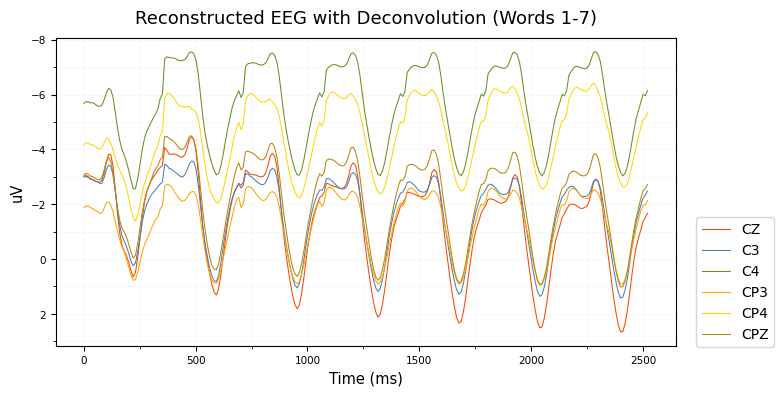

In [719]:
colors = ["orangered", "steelblue", "olivedrab", "orange", "gold", "darkgoldenrod"]
downsampled_times = np.linspace(0.0, 2520.0, 252)

reconstruct_mean = np.mean(reconstruct, axis=0)
fig, axes = plt.subplots(1, 1, figsize=(8, 4))

for (j, ch), color in zip(enumerate(ch_roi), colors):
    axes.plot(downsampled_times, reconstruct_mean[j, :], linewidth=0.75, label=ch, color=color)

axes.xaxis.set_minor_locator(AutoMinorLocator(2))
axes.yaxis.set_minor_locator(AutoMinorLocator(2))
axes.grid(linewidth=0.5, color="whitesmoke", which="major", zorder=1)
axes.grid(linewidth=0.5, color="whitesmoke", which="minor", zorder=0)
    
axes.tick_params(axis="both", which="major", labelsize=7.5)
axes.legend(bbox_to_anchor=[0.67, -0.06, 0.5, 0.5])
axes.set_ylabel("uV", fontsize=10.5, x=0.05)
axes.set_xlabel("Time (ms)", fontsize=10.5, y=0.05)
axes.set_title("Reconstructed EEG with Deconvolution (Words 1-7)", y=1.02, fontsize=13)

plt.gca().invert_yaxis()
plt.show()